# YOLO Object Detection Without a Webcam

## Goal

Run a compact YOLO11 detector on three documented sample images, turn the model
output into an inspectable table, visualize bounding boxes inline, and measure how
the confidence threshold changes the reported detections.

This replaces a webcam-first prototype that crashed its notebook kernel and
accidentally filtered COCO class 67 (`cell phone`) while describing traffic-light
detection. The default workflow here is deterministic and does not access a camera.

## Setup

Install `requirements-course-demos.txt`. On first run, Ultralytics downloads the
small `yolo11n.pt` checkpoint into ignored `data/models/`; no checkpoint is committed.

**License notice:** the Ultralytics package and YOLO11 model are offered under
[AGPL-3.0 and Enterprise terms](https://docs.ultralytics.com/models/yolo11/).
Run or reuse this demonstration only under terms appropriate to your project.
The images come from `skimage.data`: the astronaut image is public domain, and
the cat and coffee images are CC0. See `THIRD_PARTY_NOTICES.md` for links.

In [1]:
from pathlib import Path
import hashlib
import os

DATA_DIR = Path("data")
MODEL_PATH = DATA_DIR / "models" / "yolo11n.pt"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str((DATA_DIR / "ultralytics-config").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from skimage import data
from ultralytics import YOLO
from ultralytics.utils.downloads import attempt_download_asset
import ultralytics

print(f"ultralytics={ultralytics.__version__}; model cache={MODEL_PATH}")

ultralytics=8.4.155; model cache=data/models/yolo11n.pt


## Steps

### 1. Load the small COCO-pretrained detector

In [2]:
EXPECTED_MODEL_SHA256 = "0ebbc80d4a7680d14987a577cd21342b65ecfd94632bd9a8da63ae6417644ee1"
downloaded_model_path = Path(attempt_download_asset(str(MODEL_PATH)))
assert downloaded_model_path.resolve() == MODEL_PATH.resolve()
model_sha256 = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
assert model_sha256 == EXPECTED_MODEL_SHA256, "Unexpected YOLO11n checkpoint bytes"

detector = YOLO(str(MODEL_PATH))
print(f"model SHA-256={model_sha256[:12]}…; classes={len(detector.names)}; first five={list(detector.names.values())[:5]}")

model SHA-256=0ebbc80d4a76…; classes=80; first five=['person', 'bicycle', 'car', 'motorcycle', 'airplane']


### 2. Load three reusable sample images

These examples exercise different COCO classes while avoiding private photos,
webcams, and untracked course assets.

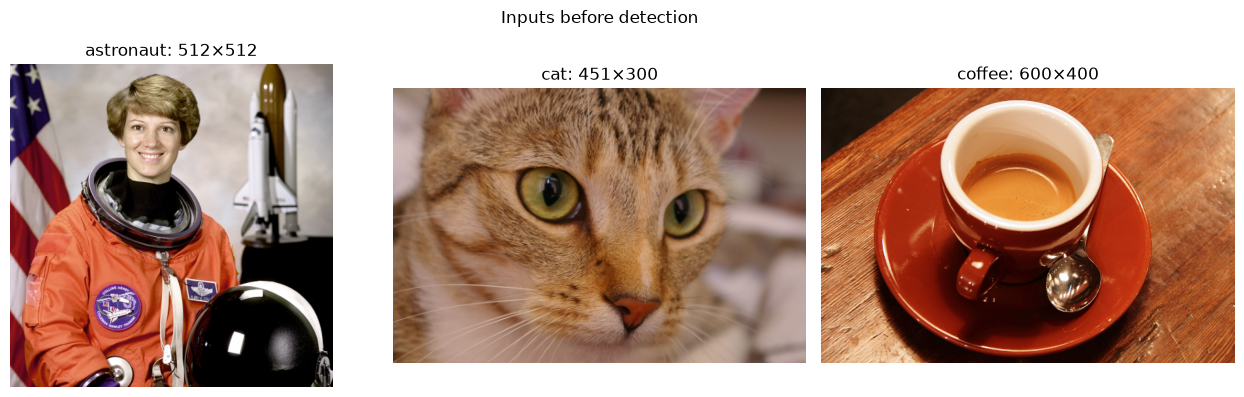

In [3]:
sample_images = {
    "astronaut": Image.fromarray(data.astronaut()),
    "cat": Image.fromarray(data.chelsea()),
    "coffee": Image.fromarray(data.coffee()),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, (name, image) in zip(axes, sample_images.items()):
    axis.imshow(image)
    axis.set_title(f"{name}: {image.width}×{image.height}")
    axis.axis("off")
fig.suptitle("Inputs before detection")
plt.tight_layout()
plt.show()

### 3. Detect objects, tabulate every box, and render predictions inline

In [4]:
detection_rows = []
rendered_images = {}
raw_results = {}

for image_name, image in sample_images.items():
    result = detector.predict(source=image, conf=0.20, imgsz=640, verbose=False)[0]
    raw_results[image_name] = result
    rendered_images[image_name] = result.plot()[..., ::-1]

    for box, confidence, class_id in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
        x1, y1, x2, y2 = [float(value) for value in box]
        detection_rows.append(
            {
                "image": image_name,
                "label": detector.names[int(class_id)],
                "confidence": float(confidence),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
            }
        )

detections = pd.DataFrame(detection_rows).sort_values(["image", "confidence"], ascending=[True, False])
detections.style.format({column: "{:.3f}" for column in ["confidence", "x1", "y1", "x2", "y2"]})

,image,label,confidence,x1,y1,x2,y2
0,astronaut,person,0.899,13.267,16.870,364.273,512.000
1,astronaut,sports ball,0.677,275.264,343.408,508.492,511.810
2,cat,cat,0.849,0.296,1.297,405.183,296.236
3,coffee,cup,0.818,170.415,17.430,421.093,317.241
4,coffee,dining table,0.784,9.714,1.544,597.960,400.000
5,coffee,spoon,0.285,324.012,215.705,406.722,329.105


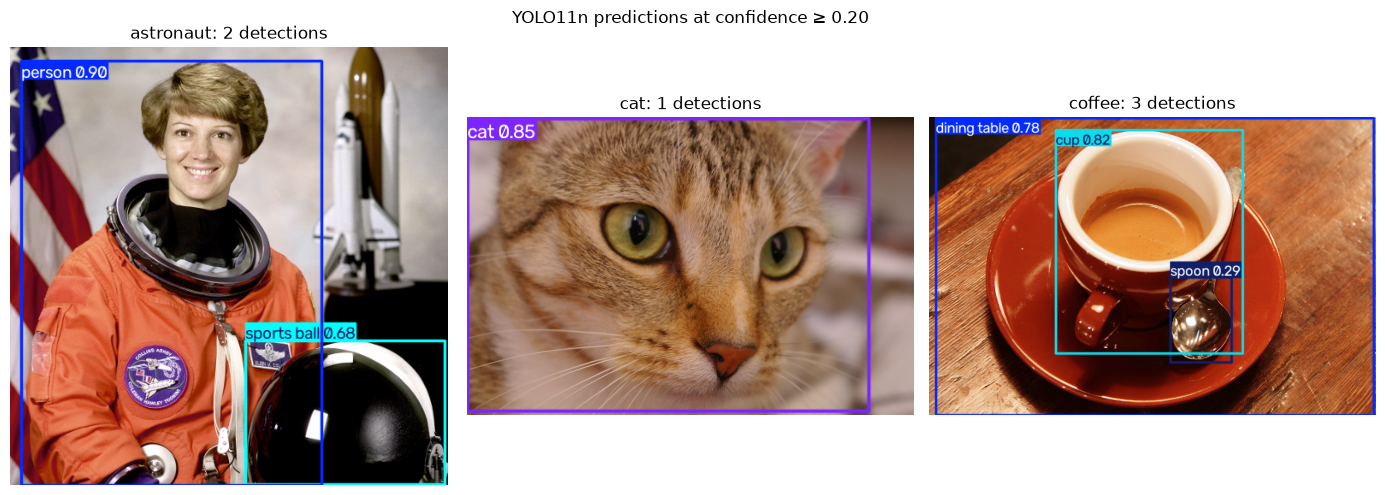

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for axis, (name, rendered) in zip(axes, rendered_images.items()):
    axis.imshow(rendered)
    axis.set_title(f"{name}: {(detections['image'] == name).sum()} detections")
    axis.axis("off")
fig.suptitle("YOLO11n predictions at confidence ≥ 0.20")
plt.tight_layout()
plt.show()

### 4. Sweep the reporting threshold

The model produces confidence scores; the application chooses which scores to
report. Increasing the threshold usually reduces detections and may remove both
false positives and difficult true positives.

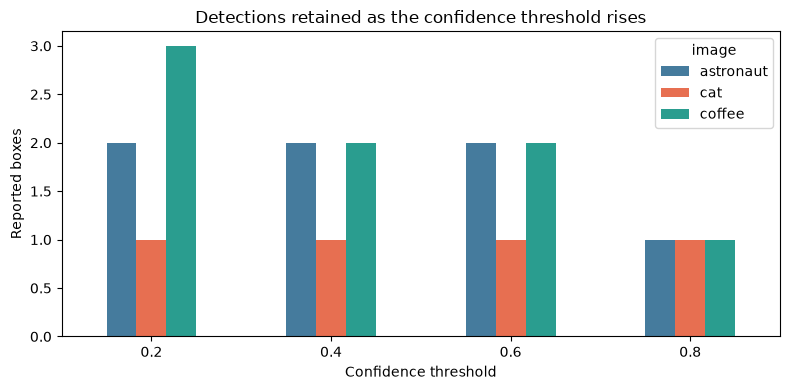

In [6]:
thresholds = np.array([0.20, 0.40, 0.60, 0.80])
threshold_rows = []
for image_name in sample_images:
    confidences = detections.loc[detections["image"] == image_name, "confidence"].to_numpy()
    for threshold in thresholds:
        threshold_rows.append(
            {"image": image_name, "threshold": threshold, "reported_boxes": int((confidences >= threshold).sum())}
        )

threshold_frame = pd.DataFrame(threshold_rows)
pivot = threshold_frame.pivot(index="threshold", columns="image", values="reported_boxes")
pivot.plot(kind="bar", figsize=(8, 4), color=["#457b9d", "#e76f51", "#2a9d8f"])
plt.title("Detections retained as the confidence threshold rises")
plt.xlabel("Confidence threshold")
plt.ylabel("Reported boxes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Checks

In [7]:
assert not detections.empty
assert detections["confidence"].between(0, 1).all()

for row in detections.itertuples(index=False):
    width, height = sample_images[row.image].size
    assert 0 <= row.x1 < row.x2 <= width
    assert 0 <= row.y1 < row.y2 <= height

labels_by_image = detections.groupby("image")["label"].apply(set).to_dict()
assert "person" in labels_by_image["astronaut"]
assert "cat" in labels_by_image["cat"]
assert "cup" in labels_by_image["coffee"]

print(f"Checks passed: {len(detections)} bounded boxes across {len(sample_images)} licensed images.")

Checks passed: 6 bounded boxes across 3 licensed images.


## Next Steps

- Evaluate precision and recall on a labeled dataset instead of judging three images.
- Compare the nano model with larger checkpoints under the same latency budget.
- Add video or webcam input only as an explicit opt-in, with camera consent and `try/finally` cleanup.
- For a domain-specific detector, document the training data, annotation quality, license, and class definitions.

Bounding boxes and confidence scores are model predictions, not verified facts.
Applications should choose thresholds from measured error costs and should not use
this educational checkpoint for safety-critical decisions.